# Loan Default Probability

# 1. XÁC ĐỊNH BÀI TOÁN

Xử lý các dữ liệu missing, encoding, loại biến không logic, target default, correlation filter trong giai đoạn từ năm 2007 đến quý III năm 2017 của Lending Club.

Bộ dữ liệu này chứa hơn 887 nghìn quan sát và 150 biến, trong đó có một biến mô tả trạng thái của khoản vay.

# 2. DOWNLOAD PACKAGE VÀ DATASET

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

from pickle import dump
from pickle import load

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
loans = pd.read_csv('/content/loan_dataset.csv', encoding='utf-8')

In [ ]:
dataset = loans

In [ ]:
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
dataset

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,38098114,NaN,15000.0,15000.0,15000.0,60 months,12.39,336.64,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,36805548,NaN,10400.0,10400.0,10400.0,36 months,6.99,321.08,A,A3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,37842129,NaN,21425.0,21425.0,21425.0,60 months,15.59,516.36,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,37612354,NaN,12800.0,12800.0,12800.0,60 months,17.14,319.08,D,D4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,37662224,NaN,7650.0,7650.0,7650.0,36 months,13.66,260.20,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869818,6327421,NaN,8000.0,8000.0,8000.0,36 months,12.35,267.06,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
869819,6344768,NaN,17825.0,17825.0,17825.0,60 months,12.35,399.67,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
869820,6570070,NaN,3625.0,3625.0,3625.0,36 months,13.68,123.34,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
869821,4694720,NaN,21850.0,21850.0,21850.0,60 months,15.88,529.96,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


# 3. TIỀN XỬ LÝ DỮ LIỆU

## 3.1. CHUẨN BỊ BIẾN ĐẦU VÀO


In [ ]:
dataset['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,424992
Current,312354
Charged Off,112349
Late (31-120 days),10198
In Grace Period,4684
Late (16-30 days),2453
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,35


Trong đồ án này, nhóm chỉ thực hiện việc tìm hiểu sự khác biệt về các đặc điểm giữa các khoản vay đã hoàn tất, đã được thanh toán đầy đủ hoặc đã bị xóa. Và không xem xét các khoản vay đang trong tình trạng hiện hành, không đáp ứng chính sách tín dụng, bị vỡ nợ hoặc có trạng thái không xác định. Chốt lại, nhóm chỉ giữ lại các khoản vay có trạng thái "Đã thanh toán đầy đủ" hoặc "Đã xóa".

In [ ]:
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])]

dataset['loan_status'].value_counts(dropna=False)

dataset['loan_status'].value_counts(normalize=True, dropna=False)

,proportion
loan_status,
Fully Paid,0.790917
Charged Off,0.209083


Khoảng 79% số khoản vay còn lại đã được thanh toán đầy đủ và 21% đã bị xóa sổ, hiện tại nhóm đang gặp phải vấn đề phân loại mất cân bằng.

In [ ]:
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)

## 3.2. PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU

Tập dữ liệu đầy đủ có 150 đặc trưng cho mỗi khoản vay.
Nhóm thực hiện loại bỏ các đặc trưng trong các bước sau bằng các phương pháp khác nhau:
* Loại bỏ các đặc trưng có hơn 80% giá trị bị thiếu

* Loại bỏ các đặc trưng không có ý nghĩa dự báo lúc xét duyệt vay

* Loại bỏ các đặc trưng có tương quan thấp (< 0.03) với biến dự đoán

### 3.2.1. Loại bỏ các đặc trưng có hơn 80% giá trị bị thiếu

Đầu tiên, tính toán tỷ lệ dữ liệu thiếu cho từng đặc trưng:

In [ ]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

,0
member_id,1.000000
next_pymnt_d,1.000000
orig_projected_additional_accrued_interest,0.999918
sec_app_mths_since_last_major_derog,0.999738
hardship_length,0.999514
deferral_term,0.999514
hardship_end_date,0.999514
hardship_reason,0.999514
hardship_start_date,0.999514
hardship_type,0.999514


In [ ]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.8].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_record', 'mths_since_rcnt_il', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_major_derog', 'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_open_act_il', 'sec_app_revol_util', 'settlement_amoun

In [ ]:
len(drop_list)

54

In [ ]:
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(537341, 96)

### 3.2.2. Loại bỏ các đặc trưng không có ý nghĩa dự báo lúc xét duyệt vay

Để lọc thêm các đặc trưng, nhóm kiểm tra qua mô tả trong dữ liệu và giữ lại các đặc trưng mà nhóm cho là không có ý nghĩa dự báo lúc xét duyệt vay.

Dưới đây là quy trình mã hoá và xoá bỏ các dữ liệu không cần thiết

In [ ]:
print(sorted(dataset.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_

Danh sách các đặc trưng được lưu giữ:

In [ ]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code','last_pymnt_amnt','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',"bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]

len(keep_list)

40

In [ ]:
drop_list = [col for col in dataset.columns if col not in keep_list]

dataset.drop(labels=drop_list, axis=1, inplace=True)

dataset.shape

(537341, 39)

### 3.2.3. Loại bỏ các đặc trưng có tương quan thấp (< 0.03) với biến dự đoán

In [ ]:
dataset.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,open_acc,pub_rec,...,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,pub_rec_bankruptcies,charged_off
count,537341.000000,537341.000000,537341.000000,537341.000000,5.373410e+05,537332.000000,537341.00000,537341.000000,537341.000000,537341.000000,...,497555.000000,497547.000000,492507.000000,492173.000000,497554.000000,497554.000000,497554.000000,497554.000000,536643.000000,537341.000000
mean,14286.262169,14266.072382,13.269495,431.855909,7.478396e+04,17.850735,694.92944,698.929521,11.535634,0.215197,...,4.692287,13326.428667,9133.245391,62.363967,182.310997,12.680356,1.792768,5.705925,0.136620,0.209083
std,8411.018418,8401.201083,4.430976,250.230145,6.307248e+04,8.432184,31.12116,31.121557,5.340624,0.600126,...,3.089181,15974.661665,14203.278228,27.426126,92.417939,15.699504,2.107097,3.205948,0.381078,0.406654
min,500.000000,500.000000,5.320000,4.930000,0.000000e+00,0.000000,625.00000,629.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,8000.000000,9.990000,251.360000,4.500000e+04,11.650000,670.00000,674.000000,8.000000,0.000000,...,2.000000,3101.000000,1244.000000,42.100000,118.000000,4.000000,0.000000,3.000000,0.000000,0.000000
50%,12000.000000,12000.000000,12.990000,373.220000,6.450000e+04,17.350000,685.00000,689.000000,11.000000,0.000000,...,4.000000,7351.000000,4037.000000,66.100000,165.000000,8.000000,1.000000,5.000000,0.000000,0.000000
75%,20000.000000,20000.000000,15.990000,568.360000,9.000000e+04,23.600000,710.00000,714.000000,14.000000,0.000000,...,6.000000,18520.500000,10837.000000,86.300000,230.000000,15.000000,3.000000,7.000000,0.000000,0.000000
max,40000.000000,40000.000000,30.990000,1587.230000,8.900060e+06,999.000000,845.00000,850.000000,90.000000,86.000000,...,53.000000,497484.000000,559912.000000,339.600000,842.000000,372.000000,47.000000,57.000000,12.000000,1.000000


#### PHÂN TÍCH CÁC BIẾN ĐẶC TRƯNG RỜI RẠC

In [ ]:
dataset[['id','emp_title','title','zip_code']].describe()

,id,emp_title,title,zip_code
count,537341,506289,537265,537341
unique,537341,175626,34131,916
top,6520133,Teacher,Debt consolidation,945xx
freq,1,8651,272271,6122


In [ ]:
dataset.drop(['id','emp_title','title','zip_code'], axis=1, inplace=True)

In [ ]:
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))

In [ ]:
dataset.groupby('term')['charged_off'].value_counts(normalize=True).loc[:,1]

,proportion
term,
36,0.162648
60,0.346105


Các khoản vay có thời hạn 5 năm có khả năng bị xóa nợ cao gấp hơn hai lần so với các khoản vay có thời hạn 3 năm.

In [ ]:
dataset['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)

dataset['emp_length'].replace('< 1 year', '0 years', inplace=True)

def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])

dataset['emp_length'] = dataset['emp_length'].apply(emp_length_to_int)

<Axes: xlabel='emp_length'>

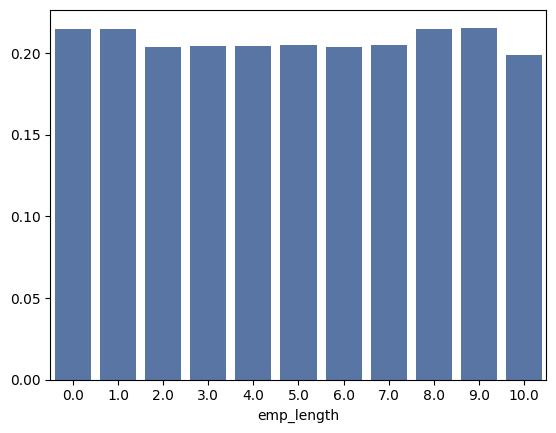

In [ ]:
charge_off_rates = dataset.groupby('emp_length')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

Tình trạng khoản vay dường như không thay đổi nhiều theo thời gian làm việc trung bình, do đó đặc trưng này bị loại bỏ.

In [ ]:
dataset.drop(['emp_length'], axis=1, inplace=True)

<Axes: xlabel='sub_grade'>

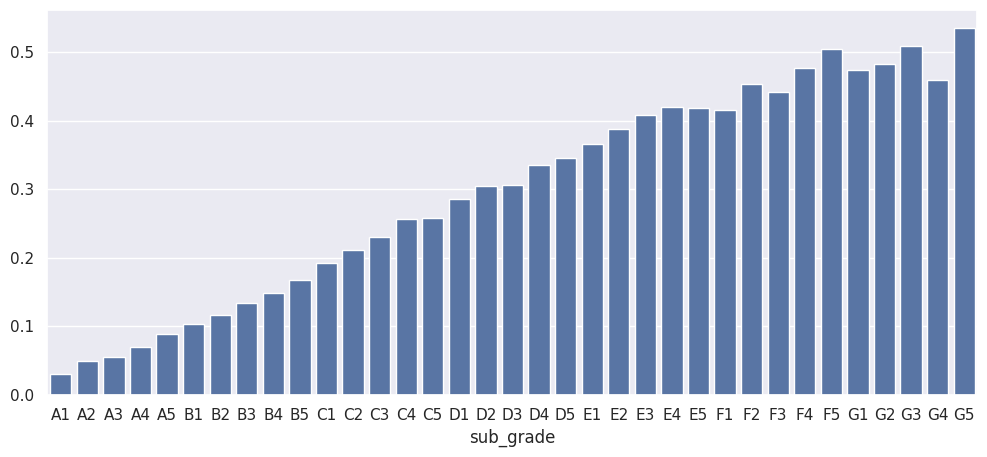

In [ ]:
charge_off_rates = dataset.groupby('sub_grade')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.set(rc={'figure.figsize':(12,5)})
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

Có một xu hướng rõ rệt cho thấy xác suất khoản vay bị ghi nhận là nợ xấu tăng lên khi mức subgrade trở nên thấp hơn.

In [ ]:
dataset['earliest_cr_line'] = dataset['earliest_cr_line'].apply(lambda s: int(s[-4:]))

#### PHÂN TÍCH BIẾN ĐẶC TRƯNG LIÊN TỤC

In [ ]:
dataset[['annual_inc']].describe()

,annual_inc
count,5.373410e+05
mean,7.478396e+04
std,6.307248e+04
min,0.000000e+00
25%,4.500000e+04
50%,6.450000e+04
75%,9.000000e+04
max,8.900060e+06


Thu nhập hàng năm dao động từ 0 đến 9.550.000 đô la, với giá trị trung vị là 65.000 đô la. Do phạm vi thu nhập rộng, nhóm thực hiện phép biến đổi logarit cho biến thu nhập hàng năm.

In [ ]:
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x: np.log10(x+1))
dataset.drop('annual_inc', axis=1, inplace=True)

In [ ]:
dataset[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


Vì hệ số tương quan giữa điểm FICO thấp và cao là 1, nên tốt hơn hết là chỉ giữ lại một đặc điểm duy nhất, đó là điểm FICO trung bình.

In [ ]:
dataset['fico_score'] = 0.5*dataset['fico_range_low'] + 0.5*dataset['fico_range_high']

dataset.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

In [ ]:
dataset['charged_off'].value_counts()

,count
charged_off,
0,424992
1,112349


#### LOẠI BỎ CÁC GIÁ TRỊ TƯƠNG QUAN <0.03

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
categorical_feature_mask = dataset.dtypes==object
categorical_cols = dataset.columns[categorical_feature_mask].tolist()

In [ ]:
categorical_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [ ]:
le = LabelEncoder()
dataset[categorical_cols] = dataset[categorical_cols].apply(lambda col: le.fit_transform(col))
dataset[categorical_cols].head(10)

,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,2,10,5,1,2,45,1,0
1,0,2,1,0,1,4,1,0
2,3,15,5,1,1,24,1,0
4,2,12,5,1,2,3,0,0
5,2,12,5,1,2,31,0,0
6,1,9,1,1,4,23,0,0
7,1,8,4,2,2,45,1,0
8,2,13,5,1,1,47,0,0
9,1,8,5,0,2,20,0,0
10,1,9,5,2,2,22,0,0


In [ ]:
correlation = dataset.corr()
correlation_chargeOff = abs(correlation['charged_off'])

In [ ]:
correlation_chargeOff.sort_values(ascending=False)

,charged_off
charged_off,1.000000
last_pymnt_amnt,0.377670
sub_grade,0.272156
grade,0.266748
int_rate,0.256675
term,0.196152
fico_score,0.138278
dti,0.129900
acc_open_past_24mths,0.105412
bc_open_to_buy,0.087337


In [ ]:
drop_list_corr = sorted(list(correlation_chargeOff[correlation_chargeOff < 0.03].index))
print(drop_list_corr)

['addr_state', 'application_type', 'initial_list_status', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'total_acc']


In [ ]:
drop_list_corr = ['pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'total_acc']

In [ ]:
dataset.drop(labels=drop_list_corr, axis=1, inplace=True)
dataset.shape

(537341, 29)

In [ ]:
dataset.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,15000.0,15000.0,60,12.39,336.64,2,10,5,1,2,...,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0,4.892100,752.0
1,10400.0,10400.0,36,6.99,321.08,0,2,1,0,1,...,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,1,4.763435,712.0
2,21425.0,21425.0,60,15.59,516.36,3,15,5,1,1,...,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0,4.804827,687.0
4,7650.0,7650.0,36,13.66,260.20,2,12,5,1,2,...,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,1,4.698979,687.0
5,9600.0,9600.0,36,13.66,326.53,2,12,5,1,2,...,3214.0,6494.0,69.2,265.0,23.0,0.0,7.0,0,4.838855,682.0


## 3.3. LẤY MẪU DỮ LIỆU

In [ ]:
loanstatus_0 = dataset[dataset["charged_off"]==0]
loanstatus_1 = dataset[dataset["charged_off"]==1]
subset_of_loanstatus_0 = loanstatus_0.sample(n=5500)
subset_of_loanstatus_1 = loanstatus_1.sample(n=5500)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1).reset_index(drop=True)
print("Current shape of dataset :",dataset.shape)
dataset.head()

Current shape of dataset : (11000, 29)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,1800.0,1800.0,36,13.35,60.96,2,11,4,0,4,...,1627.0,2441.0,82.7,167.0,6.0,0.0,9.0,0,4.568213,667.0
1,8950.0,8950.0,36,16.99,319.05,3,17,5,1,4,...,4832.0,3522.0,49.7,79.0,4.0,0.0,3.0,1,4.447174,687.0
2,11000.0,11000.0,60,11.22,240.38,1,9,4,2,2,...,1118.0,5931.0,43.5,349.0,15.0,1.0,2.0,1,4.380229,682.0
3,20000.0,20000.0,60,16.99,496.95,3,17,4,2,1,...,36298.0,7509.0,47.5,318.0,46.0,5.0,3.0,1,5.117275,692.0
4,6000.0,6000.0,36,7.69,187.17,0,3,1,1,1,...,18157.0,NaN,NaN,291.0,24.0,3.0,3.0,1,4.653222,672.0


In [ ]:
dataset.fillna(dataset.mean(),inplace = True)

# 4. ĐÁNH GIÁ CÁC THUẬT TOÁN VÀ MÔ HÌNH

## 4.1. CHIA TẬP HUẤN LUYỆN/TEST

In [ ]:
Y= dataset["charged_off"]
X = dataset.loc[:, dataset.columns != 'charged_off']
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [ ]:
dataset['charged_off'].value_counts()

,count
charged_off,
0,5500
1,5500


## 4.2. TIÊU CHÍ KIỂM TRA VÀ ĐÁNH GIÁ


In [ ]:
num_folds = 10
seed = 7
scoring = 'roc_auc'

## 4.3. SO SÁNH CÁC MÔ HÌNH VÀ THUẬT TOÁN

### Classification Models

In [ ]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))

#Neural Network
models.append(('NN', MLPClassifier()))

#Ensable Models
# Boosting methods
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))

# Bagging methods
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))

### K-folds cross validation

In [ ]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.918907 (0.006980)
LDA: 0.921314 (0.005790)
KNN: 0.864266 (0.010407)
CART: 0.836188 (0.010070)
NB: 0.918347 (0.004839)
NN: 0.900133 (0.023887)
AB: 0.941955 (0.005753)
GBM: 0.954256 (0.004044)
RF: 0.949102 (0.004946)
ET: 0.940563 (0.005512)


### So sánh các thuật toán

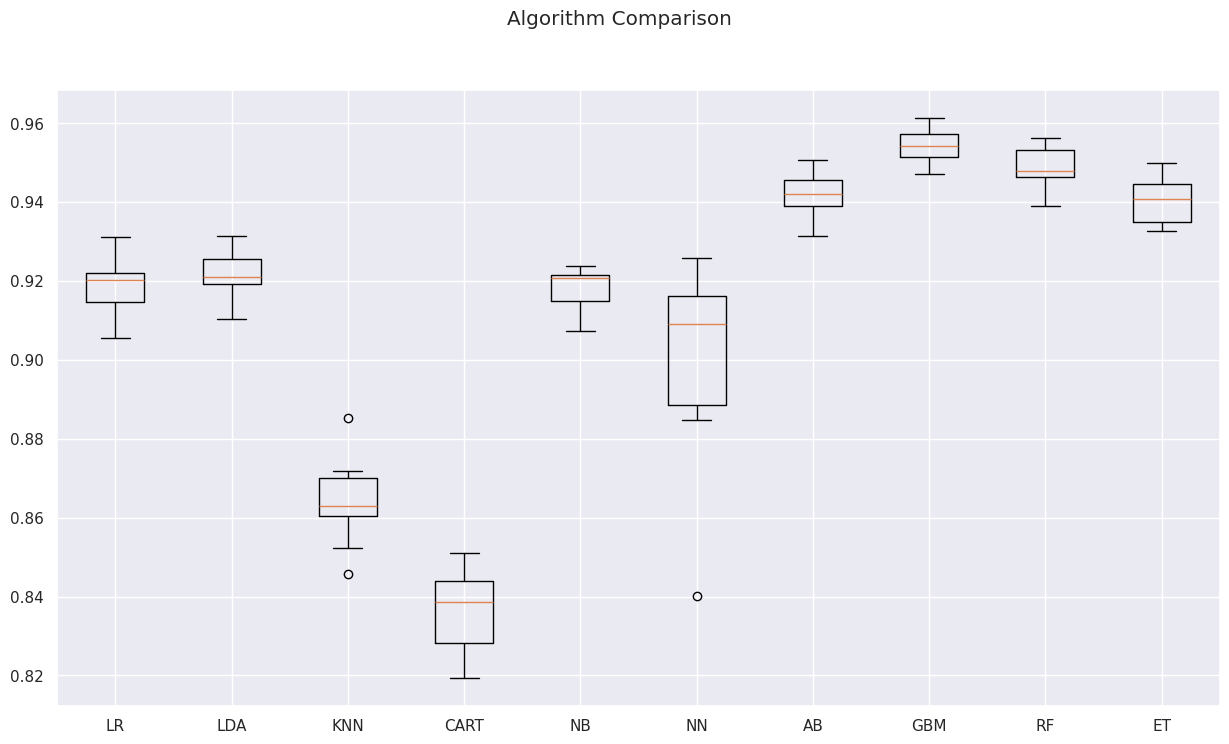

In [ ]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()

Tất cả các mô hình đều hoạt động rất tốt, vượt xa mức ngẫu nhiên (Base Rate AUC = 0.5).

Random Forest và Gradient Boosting (cùng đạt AUC = 0.95). Hai thuật toán dạng ensemble này bám sát góc trên cùng bên trái nhất, nghĩa là nhóm tối đa hóa được việc đoán đúng trong khi giữ đoán nhầm ở mức thấp nhất. Đây là hai mô hình tốt nhất để đưa vào thực thi.

# 5. ĐIỀU CHỈNH MÔ HÌNH VÀ ÁP DỤNG PP TÌM KIẾM SIÊU THAM SỐ TỐI ƯU GRID SEARCH

Vì GBM là mô hình tốt nhất, nên bước này sẽ sử dụng phương pháp Grid Search với mô hình GBM.

In [ ]:
n_estimators = [20,180]
max_depth= [3,5]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)
model = GradientBoostingClassifier()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
ranks = grid_result.cv_results_['rank_test_score']
for mean, stdev, param, rank in zip(means, stds, params, ranks):
    print("#%d %f (%f) with: %r" % (rank, mean, stdev, param))

Best: 0.956784 using {'max_depth': 5, 'n_estimators': 180}
#4 0.944293 (0.004078) with: {'max_depth': 3, 'n_estimators': 20}
#2 0.955941 (0.003992) with: {'max_depth': 3, 'n_estimators': 180}
#3 0.949815 (0.004383) with: {'max_depth': 5, 'n_estimators': 20}
#1 0.956784 (0.003465) with: {'max_depth': 5, 'n_estimators': 180}


# 6. HOÀN THIỆN MÔ HÌNH

Dựa vào các chỉ số đánh giá ở các mục trên, GBM có thể sẽ được tìm hiểu thêm, nhưng hiện tại GBM cho thấy rất nhiều triển vọng như một mô hình có độ phức tạp thấp và ổn định cho bài toán này.

Sau đây, nhóm sẽ hoàn thiện mô hình với các tham số tốt nhất được tìm thấy trong bước tinh chỉnh tham số.

## 6.1. KẾT QUẢ TRÊN TẬP DỮ LIỆU KIỂM THỬ

In [ ]:
model = GradientBoostingClassifier(max_depth= 5, n_estimators= 180)
model.fit(X_train, Y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=180)

In [ ]:
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8836363636363637
[[ 941  193]
 [  63 1003]]
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      1134
           1       0.84      0.94      0.89      1066

    accuracy                           0.88      2200
   macro avg       0.89      0.89      0.88      2200
weighted avg       0.89      0.88      0.88      2200



<Axes: xlabel='Predicted', ylabel='Actual'>

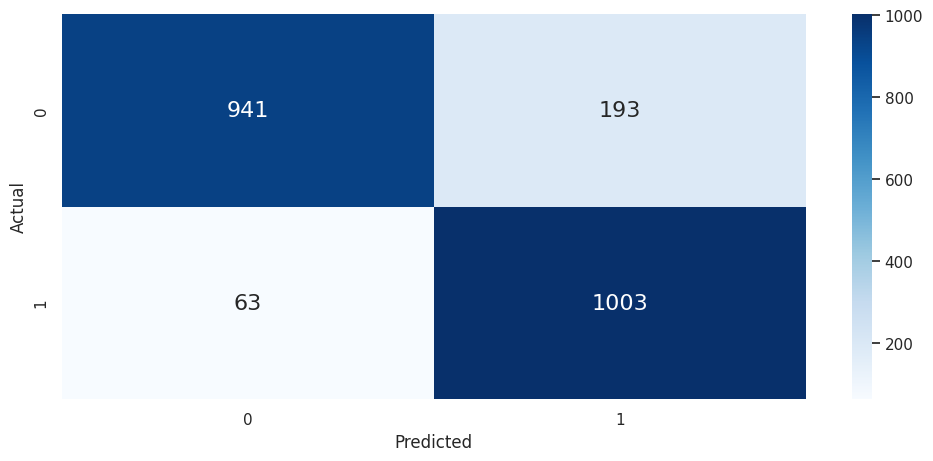

In [ ]:
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='d')

## 6.2. MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG
Dưới đây là thang đo đánh giá mức độ quan trọng của các đặc trưng trong mô hình GBM

[7.40071508e-03 1.85138937e-02 3.76908878e-02 1.69059428e-02
 2.66420249e-02 2.18504525e-03 5.30274041e-02 5.14953772e-04
 3.00017084e-03 1.94925655e-03 4.05391899e-03 1.34661310e-02
 6.96360788e-03 3.89826132e-03 9.93191564e-03 2.59622668e-03
 7.17861891e-01 0.00000000e+00 1.44063403e-02 1.10942661e-02
 6.73124314e-03 9.18110217e-03 4.16799946e-03 5.89833577e-03
 3.41070773e-03 3.40392116e-03 7.29777409e-03 7.80606291e-03]


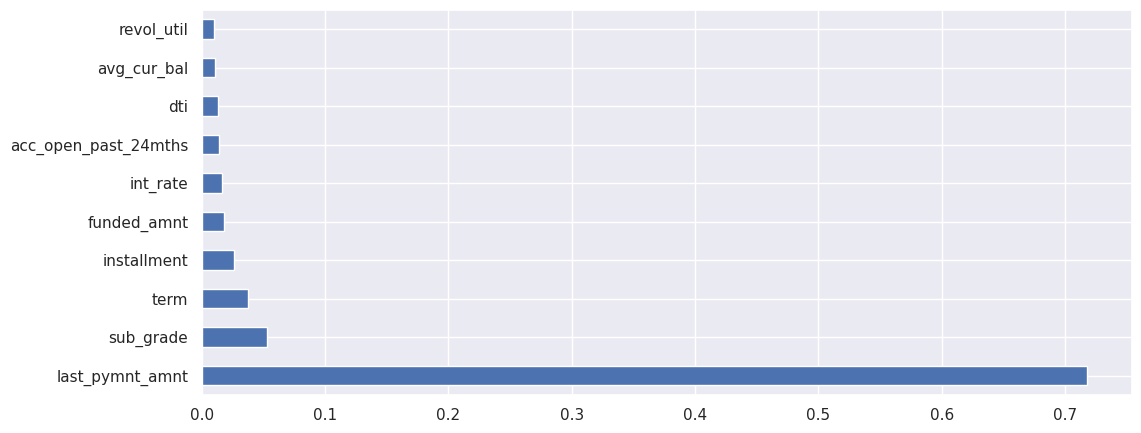

In [ ]:
print(model.feature_importances_)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
pyplot.show()

__KẾT LUẬN__:

Các nhiệm vụ mà nhóm đã làm được trong phần này:

Nhóm em đã làm rõ rằng bước tiền xử lý dữ liệu là một trong những bước quan trọng nhất. Nhóm đã giải quyết vấn đề này bằng cách thực hiện loại bỏ đặc trưng bằng cách sử dụng các kỹ thuật khác nhau như đánh giá các đặc trưng có ý nghĩa với mô hình, mức độ tương quan và chất lượng dữ liệu của đặc trưng.

Nhóm đã minh họa rằng có thể có nhiều cách khác nhau để xử lý và phân tích dữ liệu và chuyển đổi dữ liệu thành định dạng có thể sử dụng được cho mô hình.

Cuối cùng, nhóm đã phân tích tầm quan trọng của các đặc trưng và nhận thấy rằng kết quả khá tốt và trực quan.

In [ ]:
def predict_default_probability(model, customer_data):
    probability = model.predict_proba(customer_data)[0][1]

    print(f"Khách hàng này có {probability * 100:.2f}% nguy cơ vỡ nợ tín dụng.")

    if probability > 0.5:
        print("CẢNH BÁO: Rủi ro cao. Khuyến nghị TỪ CHỐI khoản vay!")
    else:
        print("ĐÁNH GIÁ: Rủi ro thấp. Khuyến nghị CHẤP THUẬN khoản vay.")

    return probability

print("--- DEMO HỆ THỐNG SCORING ---")
new_customer_mock_data = X_validation.iloc[[0]]
predict_default_probability(model, new_customer_mock_data)

--- DEMO HỆ THỐNG SCORING ---
Khách hàng này có 0.55% nguy cơ vỡ nợ tín dụng.
ĐÁNH GIÁ: Rủi ro thấp. Khuyến nghị CHẤP THUẬN khoản vay.


np.float64(0.0055248983786205874)